# Matemáticas aplicadas. Parcial 3

#### Samuel Acosta Aristizábal - 1000900513
#### Manuela Caro Villada - 1000124254
#### Jeronimo Velasquez Escobar - 1000116682

In [ ]:
## Se inicialializa el programa y se importan las librerias necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Ejercicio numero 1

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame
X = cancer.data[['mean radius', 'mean texture']]
y = cancer.target
X

,mean radius,mean texture
0,17.99,10.38
1,20.57,17.77
2,19.69,21.25
3,11.42,20.38
4,20.29,14.34
...,...,...
564,21.56,22.39
565,20.13,28.25
566,16.60,28.08
567,20.60,29.33


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# for col in X.columns:
#     mean = X[col].mean()
#     std = X[col].std()
#     X[col] = (X[col] - mean) / std
# X.mean()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Verificacion
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[-2.92806072e-16  6.24652955e-16]
[1. 1.]


In [ ]:
y_train_svm = (2*y_train - 1).values
y_test_svm = (2*y_test - 1).values

In [ ]:
class LinearSVM_SGD:

    def __init__(self, lr=0.01, C=1.0, epochs=1000):
        self.lr = lr
        self.C = C
        self.epochs = epochs
        self.cost_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):

            idx = np.random.randint(0, n_samples)

            xi = X[idx]
            yi = y[idx]

            condition = yi * (np.dot(xi, self.w) + self.b)

            if condition >= 1:
                grad_w = self.w
                grad_b = 0
            else:
                grad_w = self.w - self.C * yi * xi
                grad_b = -self.C * yi

            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

            # costo completo (para graficar)
            margins = y * (X @ self.w + self.b)
            hinge_loss = np.maximum(0, 1 - margins)
            cost = 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge_loss)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

In [ ]:
class LinearSVM_GD:

    def __init__(self, lr=0.01, C=1.0, epochs=1000):
        self.lr = lr
        self.C = C
        self.epochs = epochs
        self.cost_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):

            margins = y * (X @ self.w + self.b)

            # identificar puntos que violan el margen
            mask = margins < 1

            # gradiente promedio
            grad_w = self.w - self.C * np.mean((y[mask][:, None] * X[mask]), axis=0)
            grad_b = -self.C * np.mean(y[mask]) if np.any(mask) else 0

            # actualización
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

            # calcular costo
            hinge_loss = np.maximum(0, 1 - margins)
            cost = 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge_loss)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

In [ ]:
svm_SGD = LinearSVM_SGD(lr=0.05, C=1.0, epochs=3000)
svm_SGD.fit(X_train_scaled, y_train_svm)

In [ ]:
svm_GD = LinearSVM_GD(lr=0.1, C=1.0, epochs=3000)
svm_GD.fit(X_train_scaled, y_train_svm)

In [ ]:
print("Pesos:", svm_GD.w)
print("Bias:", svm_GD.b)
preds = svm_GD.predict(X_test_scaled)

accuracy = np.mean(preds == y_test_svm)
print("Accuracy:", accuracy)

Pesos: [-0.54564892 -0.23604662]
Bias: 0.5795540235938501
Accuracy: 0.8421052631578947


In [ ]:
print("Pesos:", svm_SGD.w)
print("Bias:", svm_SGD.b)
preds = svm_SGD.predict(X_test_scaled)

accuracy = np.mean(preds == y_test_svm)
print("Accuracy:", accuracy)

Pesos: [-0.52794614 -0.32687575]
Bias: 0.49999999999999983
Accuracy: 0.8508771929824561


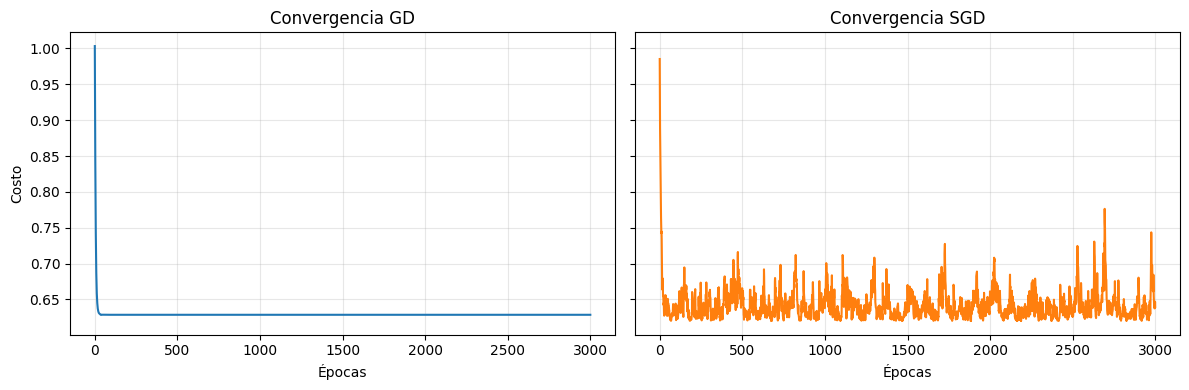

In [ ]:
# Cambio del costo en subplots distintos
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(svm_GD.cost_history, color="tab:blue")
axes[0].set_title("Convergencia GD")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Costo")
axes[0].grid(True, alpha=0.3)

axes[1].plot(svm_SGD.cost_history, color="tab:orange")
axes[1].set_title("Convergencia SGD")
axes[1].set_xlabel("Épocas")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
C_values = [0.01, 1, 100, 10]  # valor adicional = 10

In [ ]:
def plot_svm(ax, model, X, y, title):

    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.7)

    x1 = np.linspace(X[:,0].min(), X[:,0].max(), 100)

    w1, w2 = model.w
    b = model.b

    # frontera decisión
    x2 = (-w1*x1 - b) / w2
    ax.plot(x1, x2, 'k')

    # márgenes
    x2_margin1 = (-w1*x1 - b + 1) / w2
    x2_margin2 = (-w1*x1 - b - 1) / w2

    ax.plot(x1, x2_margin1, 'k--')
    ax.plot(x1, x2_margin2, 'k--')

    ax.set_title(title)

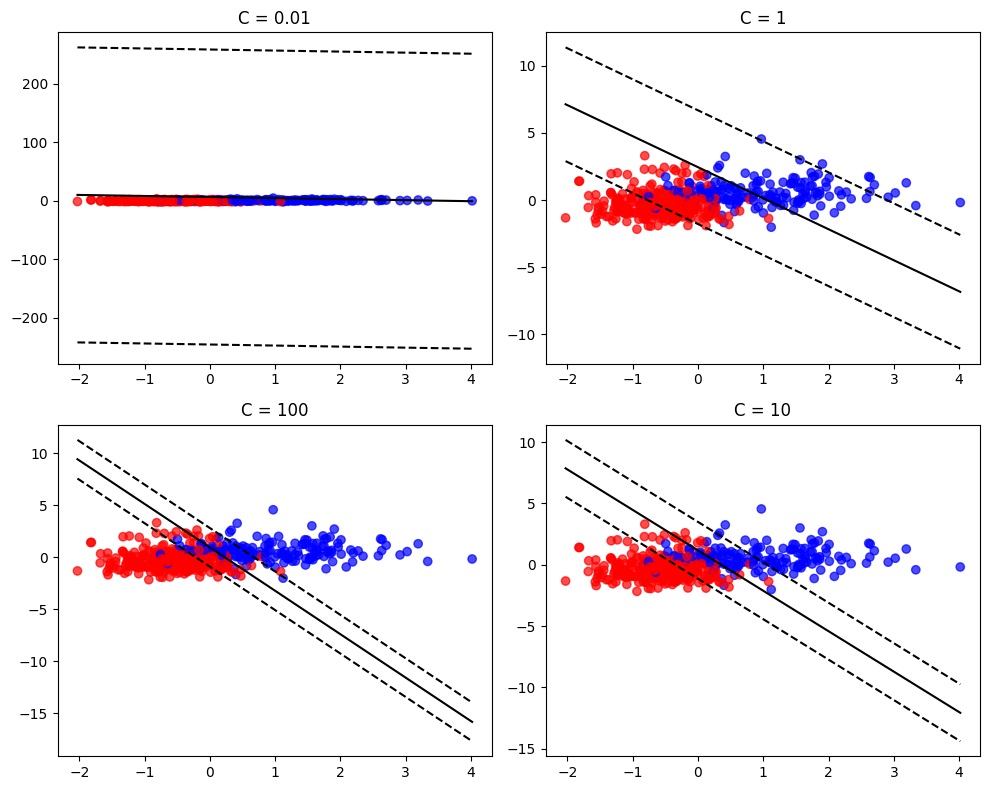

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

for ax, C in zip(axes.flatten(), C_values):

    model = LinearSVM_GD(lr=0.01, C=C, epochs=1000)
    model.fit(X_train_scaled, y_train_svm)

    plot_svm(ax, model, X_train_scaled, y_train_svm, f"C = {C}")

plt.tight_layout()
plt.show()

#### Ejercicio 1.4


##### (a) Oscilaciones en SGD

Sí, la curva de costo del SGD presenta oscilaciones.

Esto ocurre porque el gradiente se calcula utilizando un único punto aleatorio en cada iteración, lo que introduce ruido en la dirección de descenso. A diferencia del GD, que usa el gradiente promedio sobre todos los datos, el SGD produce actualizaciones estocásticas que pueden incrementar temporalmente el costo.

Desde una perspectiva computacional, el SGD es indispensable cuando el conjunto de datos es extremadamente grande (por ejemplo, un millón de imágenes médicas), ya que calcular el gradiente completo en cada iteración sería prohibitivo en términos de memoria y tiempo. El SGD permite actualizaciones rápidas y escalables.

---

##### (b) Efecto geométrico de C

Al aumentar el valor de C:

El margen se vuelve más estrecho.

Se penalizan más severamente las violaciones.

Disminuye la tolerancia a errores.

Geométricamente, el hiperplano se ajusta más a los datos.

En un contexto clínico, un C moderado (por ejemplo C=1 o C=10) probablemente generalice mejor, ya que evita tanto el sobreajuste como el subajuste.

---

##### (c) ¿Cuáles son los vectores de soporte?

Son los puntos que cumplen:

yi​(wTxi​+b)≤1

Es decir:

Puntos sobre el margen

Puntos dentro del margen

Puntos mal clasificados

Son los únicos que contribuyen al gradiente.

---
##### (d) ¿Qué pasa con puntos bien clasificados y fuera del margen?

Si:

yi​(wTxi​+b)>1
	​

Entonces:

max(0,1−yi​(wTxi​+b))=0

y su contribución al gradiente es cero.

Matemáticamente:

∂w/∂J​=w

Es decir, el punto no influye en la actualización.

Esto es una propiedad fundamental del:

Support Vector Machine

solo los vectores de soporte afectan la solución.

# Ejercicio 2

In [ ]:
# Importaciones

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.misc import ascent
from mpl_toolkits.mplot3d import Axes3D

# Estilo global para figuras más limpias
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Cargar imagen
img = ascent().astype(float)          # shape: (512, 512), valores 0–255
print(f'Tamaño de la imagen: {img.shape}  |  min={img.min():.0f}  max={img.max():.0f}')

Tamaño de la imagen: (512, 512)  |  min=0  max=255


C:\Users\TUF GAMING\AppData\Local\Temp\ipykernel_8032\3166333377.py:13: DeprecationWarning: scipy.misc.ascent has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.ascent instead.
  img = ascent().astype(float)          # shape: (512, 512), valores 0–255


## 2.1 La imagen como superficie

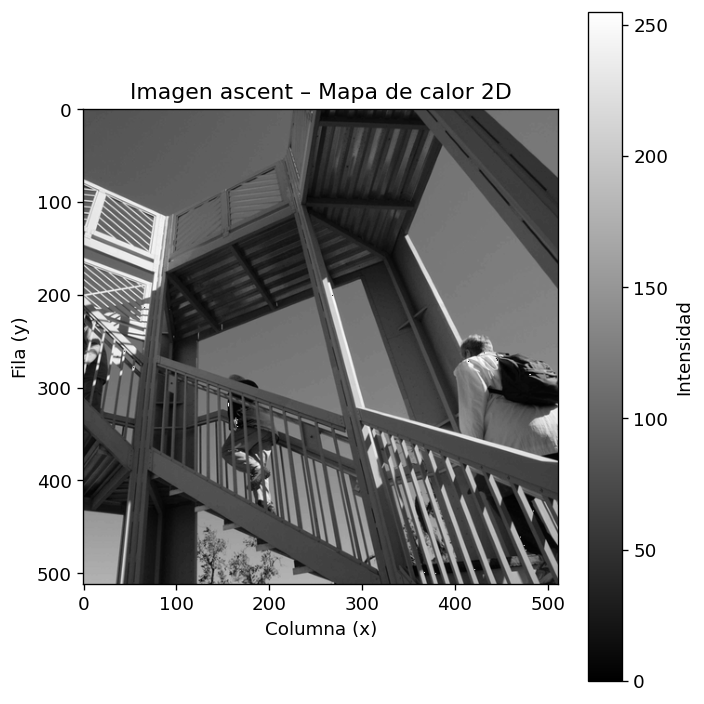

In [ ]:
# Mapa de calor
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(img, cmap='gray', origin='upper')
plt.colorbar(im, ax=ax, label='Intensidad')
ax.set_title('Imagen ascent – Mapa de calor 2D')
ax.set_xlabel('Columna (x)')
ax.set_ylabel('Fila (y)')
plt.tight_layout()
plt.show()

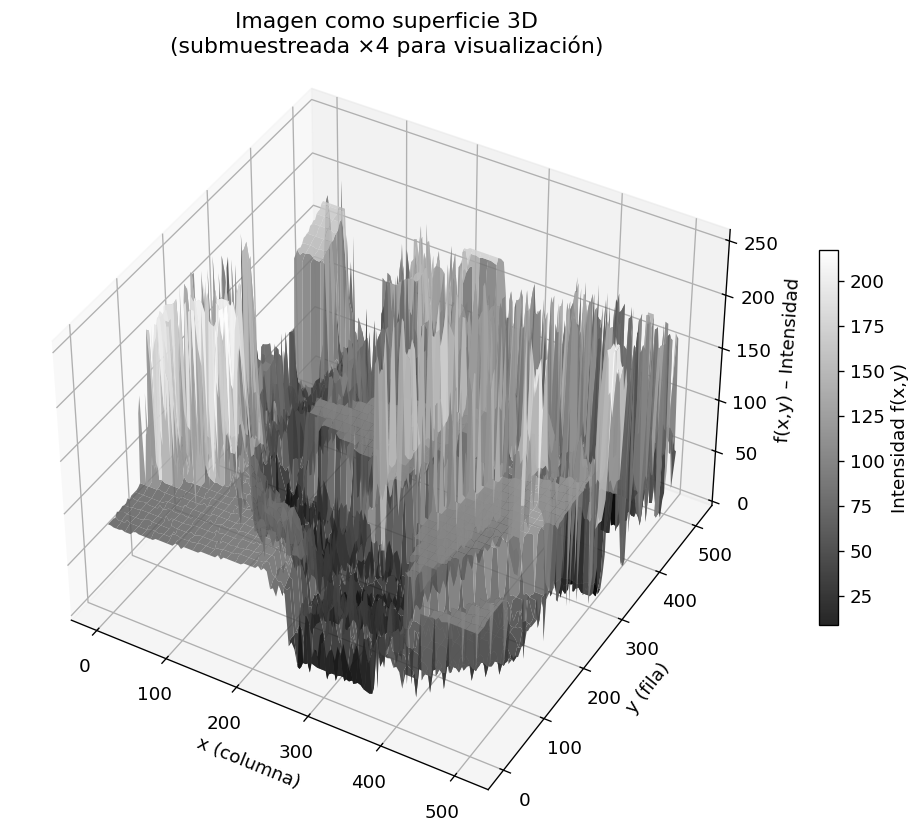

In [ ]:
# Superficie de intensidad

step = 4
img_sub = img[::step, ::step]
rows, cols = img_sub.shape

X_3d = np.arange(cols) * step
Y_3d = np.arange(rows) * step
X_3d, Y_3d = np.meshgrid(X_3d, Y_3d)

fig = plt.figure(figsize=(10, 7))
ax3d = fig.add_subplot(111, projection='3d')
surf = ax3d.plot_surface(
    X_3d, Y_3d, img_sub,
    cmap='gray', linewidth=0, antialiased=True, alpha=0.85
)
fig.colorbar(surf, ax=ax3d, shrink=0.5, label='Intensidad f(x,y)')
ax3d.set_title('Imagen como superficie 3D\n(submuestreada ×4 para visualización)')
ax3d.set_xlabel('x (columna)')
ax3d.set_ylabel('y (fila)')
ax3d.set_zlabel('f(x,y) – Intensidad')
ax3d.view_init(elev=40, azim=-60)
plt.tight_layout()
plt.show()

**¿Qué representan las pendientes pronunciadas en el terreno virtual?**

En la visualización 3D, el eje Z representa la intensidad del píxel (0 = negro, 255 = blanco). Una pendiente pronunciada en el terreno equivale, en la imagen original, a un cambio brusco de intensidad, es decir, un borde o contorno entre zonas claras y oscuras (por ejemplo, la arista entre una pared iluminada y una sombra profunda). Las zonas planas del terreno (mesetas) corresponden a regiones homogéneas de color uniforme, sin transiciones bruscas.

## 2.2 Curvas de Nivel

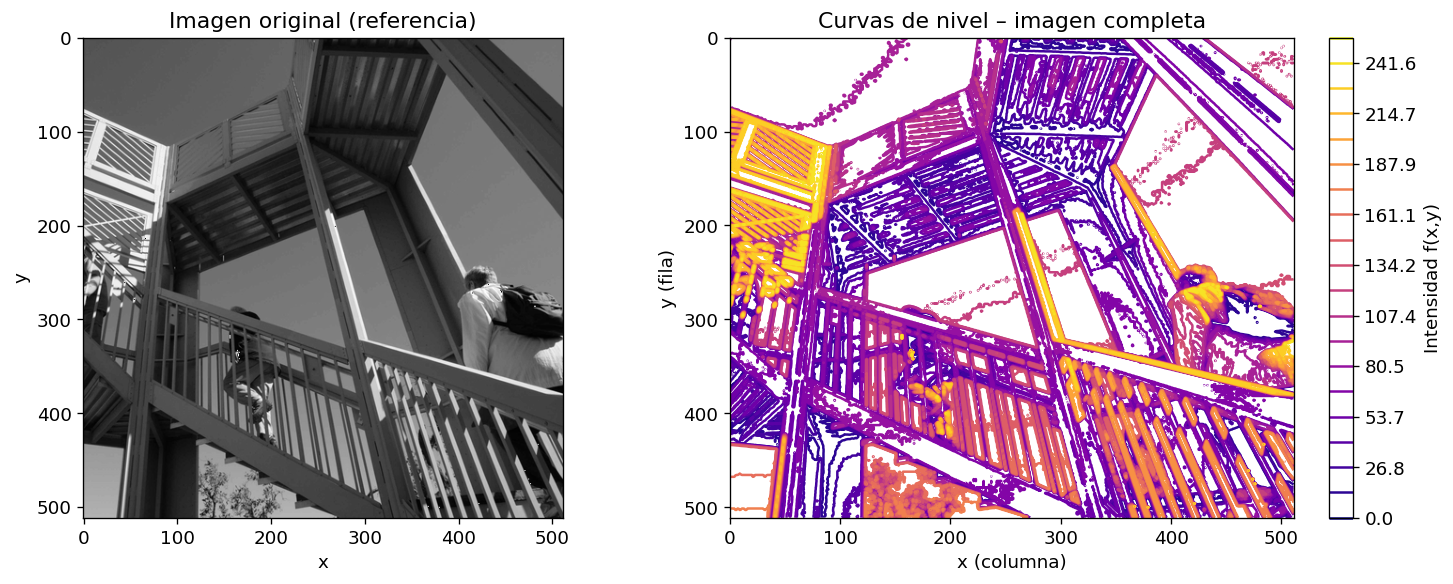

In [ ]:
# Gráfico de contorno completo

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#  Panel izquierdo: imagen original de referencia
axes[0].imshow(img, cmap='gray', origin='upper')
axes[0].set_title('Imagen original (referencia)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

#  Panel derecho: contour plot
n_levels = 20
levels = np.linspace(img.min(), img.max(), n_levels)
rows_full = np.arange(img.shape[0])
cols_full = np.arange(img.shape[1])
Xc, Yc = np.meshgrid(cols_full, rows_full)

cp = axes[1].contour(Xc, Yc, img, levels=levels, cmap='plasma')
plt.colorbar(cp, ax=axes[1], label='Intensidad f(x,y)')
axes[1].set_title('Curvas de nivel – imagen completa')
axes[1].set_xlabel('x (columna)'); axes[1].set_ylabel('y (fila)')
axes[1].invert_yaxis()   # misma orientación que imshow

plt.tight_layout()
plt.show()

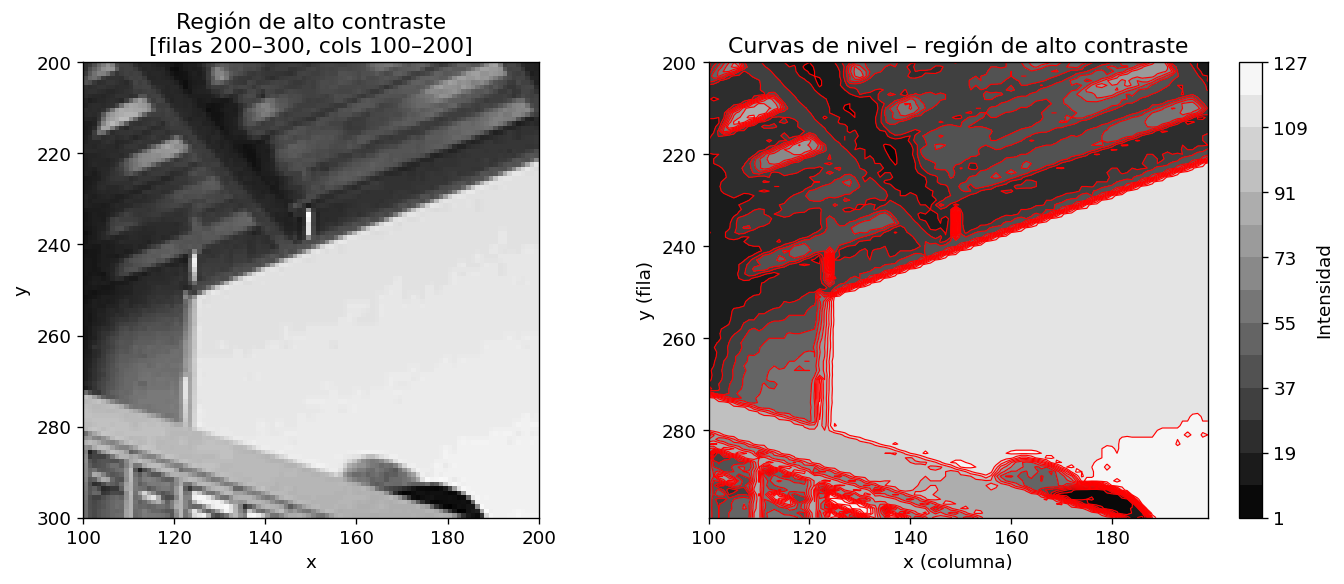

In [ ]:
# Curvas de nivel locales

# Seleccionamos una región con alto contraste (borde escalera/sombra)
r0, r1 = 200, 300   # filas
c0, c1 = 100, 200   # columnas
region = img[r0:r1, c0:c1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagen de la región
axes[0].imshow(region, cmap='gray', origin='upper',
               extent=[c0, c1, r1, r0])
axes[0].set_title(f'Región de alto contraste\n[filas {r0}–{r1}, cols {c0}–{c1}]')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Contour de la región
xr = np.arange(c0, c1)
yr = np.arange(r0, r1)
Xr, Yr = np.meshgrid(xr, yr)
levels_r = np.linspace(region.min(), region.max(), 15)
cp2 = axes[1].contourf(Xr, Yr, region, levels=levels_r, cmap='gray')
cs2 = axes[1].contour (Xr, Yr, region, levels=levels_r, colors='red', linewidths=0.7)
plt.colorbar(cp2, ax=axes[1], label='Intensidad')
axes[1].set_title('Curvas de nivel – región de alto contraste')
axes[1].set_xlabel('x (columna)'); axes[1].set_ylabel('y (fila)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**¿Cómo es la distancia entre curvas de nivel en zonas planas vs. zonas de borde?**

* **Zona plana (color uniforme):** La intensidad `f(x,y)` varía poco entre píxeles vecinos. Las curvas de nivel están muy separadas (o incluso ausentes), indicando que se necesita recorrer mucha distancia espacial para cambiar de un nivel de intensidad al siguiente. La magnitud del gradiente `‖∇f‖` es pequeña (pendiente suave).
* **Zona de borde (transición brusca):** La intensidad cambia drásticamente en pocos píxeles. Las curvas de nivel se apilan muy juntas, reflejando que pequeños desplazamientos producen grandes cambios en `f`. La magnitud del gradiente es grande (pendiente pronunciada). Así, la densidad de isolíneas es un indicador directo de la magnitud de la derivada.

### **Ejercicio 3**

# Recuperación de Trayectoria de Drones: Regresión Ridge
En este ejericio, simulamos el sensor de altitud de un dron que entrega datos ruidosos. El objetivo es recuperar la trayectoria real $f(t) = \sin(t)$ utilizando un polinomio de alto grado con **Regularización Ridge ($L_2$)**.

### Generación del Modelo Estocástico
Generamos $N = 15$ puntos de datos sintéticos equiespaciados en el intervalo $[0, 2\pi]$ siguiendo el modelo:
$$y_i = \sin(t_i) + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, 0.25^2)$$

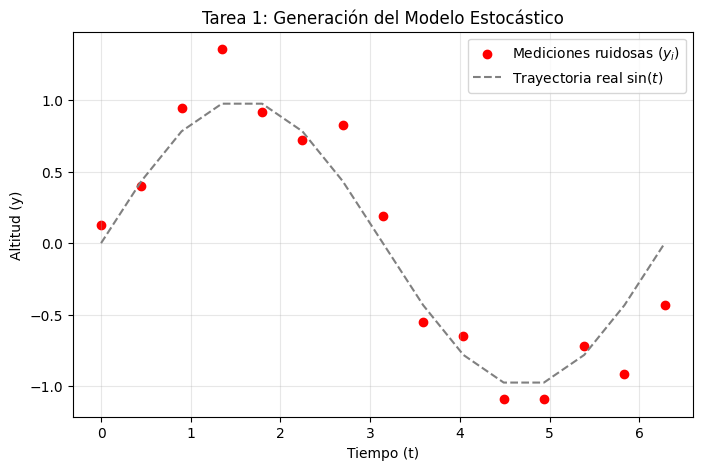

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros iniciales definidos en el enunciado
N = 15
sigma = 0.25
# Generamos N puntos equiespaciados en [0, 2π]
t = np.linspace(0, 2 * np.pi, N)
np.random.seed(42) # Semilla para que el ruido sea siempre el mismo

# Generación del modelo estocástico: y = f(t) + ruido
f_t = np.sin(t)
ruido = np.random.normal(0, sigma, N)
y = f_t + ruido

# Visualización inicial
plt.figure(figsize=(8, 5))
plt.scatter(t, y, color='red', label='Mediciones ruidosas ($y_i$)')
plt.plot(t, f_t, '--', color='gray', label=r'Trayectoria real $\sin(t)$')

plt.title("Tarea 1: Generación del Modelo Estocástico")
plt.xlabel("Tiempo (t)")
plt.ylabel("Altitud (y)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Solución del Problema de Optimización
Para modelar la trayectoria, usamos un polinomio de grado $d=10$. Debemos minimizar la función de costo con penalización:
$$J(\mathbf{w}) = \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 + \lambda \|\mathbf{w}\|_2^2$$

Utilizaremos la **solución analítica cerrada**:
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

In [2]:
def matriz_diseno(t_vec, grado):
    return np.vander(t_vec, grado + 1, increasing=True)

def resolver_ridge(t_vec, y_vec, grado, lmbda):
    X = matriz_diseno(t_vec, grado)
    I = np.eye(grado + 1)
    # Solución analítica
    A = X.T @ X + lmbda * I
    w = np.linalg.inv(A) @ X.T @ y_vec
    return w

grado = 10
# Prueba rápida con un lambda pequeño
w_ejemplo = resolver_ridge(t, y, grado, lmbda=0.1)

###El Efecto de Lambda (Experimento Visual)
Entrenamos el modelo bajo tres escenarios para observar el compromiso entre sesgo y varianza:
1. **Escenario A ($\lambda = 0$):** Sin regularización (Sobreajuste).
2. **Escenario B ($\lambda \in [0.001, 1]$):** Probaremos 3 valores en este rango.
3. **Escenario C ($\lambda = 1000$):** Regularización extrema (Subajuste).

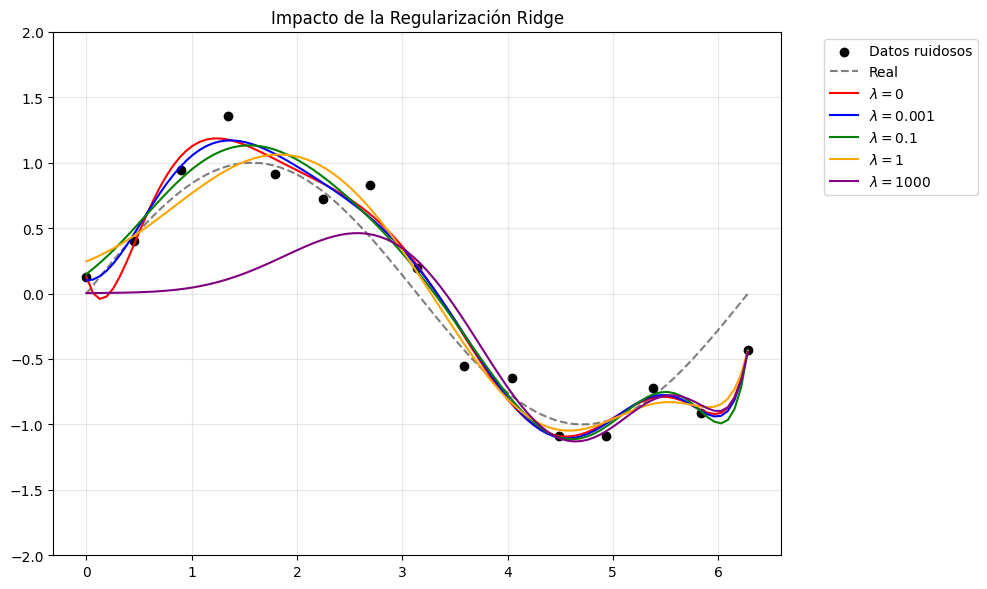

In [3]:
t_cont = np.linspace(0, 2 * np.pi, 100)
X_cont = matriz_diseno(t_cont, grado)

lambdas = [0, 0.001, 0.1, 1, 1000]
colores = ['red', 'blue', 'green', 'orange', 'purple']

plt.figure(figsize=(10, 6))
plt.scatter(t, y, color='black', label='Datos ruidosos')
plt.plot(t_cont, np.sin(t_cont), 'k--', alpha=0.5, label='Real')

pesos_escenarios = {}

for l, c in zip(lambdas, colores):
    w = resolver_ridge(t, y, grado, l)
    y_pred = X_cont @ w
    # Agregamos 'rf' para que reconozca la variable {l} y el símbolo \lambda
    plt.plot(t_cont, y_pred, color=c, label=rf'$\lambda={l}$')
    pesos_escenarios[l] = w

plt.ylim(-2, 2)
plt.title("Impacto de la Regularización Ridge")
# Colocamos la leyenda fuera para que no tape el gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Reflexión: El Efecto de Lambda en la Geometría del Modelo

Al observar la gráfica de **Impacto de la Regularización Ridge**, podemos identificar cómo el hiperparámetro $\lambda$ actúa como un control de "suavizado" para la trayectoria del dron:

* **Escenario A ($\lambda = 0$):** Representa el modelo de mínimos cuadrados ordinarios. La curva (roja) intenta pasar exactamente por cada punto ruidoso, lo que genera oscilaciones violentas. Esto es un claro ejemplo de **Sobreajuste (Overfitting)**; el modelo ha memorizado el ruido en lugar de aprender la tendencia real.
* **Escenario B ($\lambda \in [0.001, 1]$):** Con valores moderados de penalización, la curva se estabiliza. Notamos que las líneas (azul y verde) se aproximan mucho más a la función seno original (línea punteada). Aquí, la regularización Ridge logra filtrar el error del sensor, recuperando la trayectoria suave deseada.
* **Escenario C ($\lambda = 1000$):** Una penalización demasiado alta obliga a los pesos a ser casi nulos. La curva (morada) se vuelve casi una línea plana, perdiendo la forma de la trayectoria real. Esto se conoce como **Subajuste (Underfitting)**.

### Reflexión de Coeficientes
Comparamos la magnitud absoluta de los pesos $\mathbf{w}$ del **Escenario A ($\lambda=0$)** vs el **Escenario B ($\lambda=0.1$)** en escala logarítmica.

**Análisis:** La regularización Ridge penaliza los coeficientes grandes. Numéricamente, esto "suaviza" la curva porque impide que los términos de potencias altas ($t^9, t^{10}$) tengan pesos gigantescos que intenten seguir cada punto de ruido.

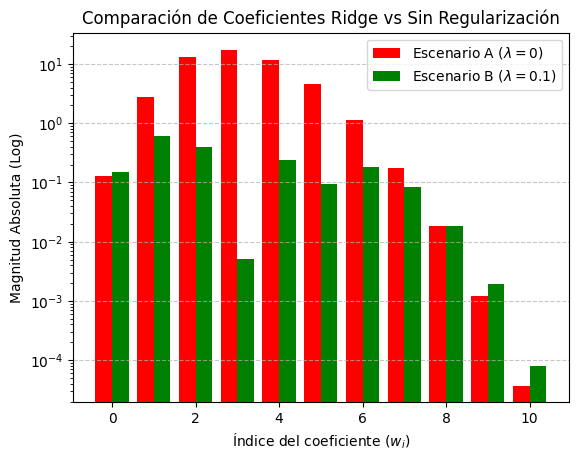

In [5]:
w_A = np.abs(pesos_escenarios[0])
w_B = np.abs(pesos_escenarios[0.1])

indices = np.arange(grado + 1)

plt.bar(indices - 0.2, w_A, width=0.4, label=r'Escenario A ($\lambda=0$)', color='red')
plt.bar(indices + 0.2, w_B, width=0.4, label=r'Escenario B ($\lambda=0.1$)', color='green')

plt.yscale('log') # Escala logarítmica solicitada en el enunciado
plt.xlabel(r'Índice del coeficiente ($w_i$)')
plt.ylabel('Magnitud Absoluta (Log)')
plt.title('Comparación de Coeficientes Ridge vs Sin Regularización')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Reflexión: Análisis Numérico de la Regularización

Al analizar el gráfico de barras que compara las magnitudes absolutas de los coeficientes $\mathbf{w}$ en escala logarítmica, podemos extraer las siguientes conclusiones fundamentales:

* **Reducción Drástica de Magnitud:** En el **Escenario A ($\lambda=0$)**, los coeficientes presentan magnitudes extremadamente elevadas, especialmente en términos de grado medio y alto. Esto ocurre porque el modelo intenta ajustar el polinomio a cada punto de ruido, requiriendo pesos grandes para generar oscilaciones rápidas.
* **Efecto de la Penalización $L_2$:** En el **Escenario B ($\lambda=0.1$)**, se observa que casi todos los coeficientes disminuyen en varios órdenes de magnitud. La función de costo Ridge añade el término $\lambda \|\mathbf{w}\|_2^2$, lo que impone un "costo" matemático al tamaño de los pesos.
* **Suavizado de la Curva:** Coeficientes pequeños impiden que el polinomio reaccione de forma violenta ante variaciones aleatorias (ruido). Al atenuar la influencia de los términos de alto grado, el modelo representa la tendencia principal de la trayectoria.
* **Estabilidad del Sistema:** Matemáticamente, sumar $\lambda \mathbf{I}$ a la matriz $\mathbf{X}^T \mathbf{X}$ asegura que la matriz sea invertible y menos sensible a errores numéricos, evitando la inestabilidad que menciona el enunciado.

## Conclusión General y Aplicación Logística

A través de este análisis, se ha determinado que un valor de **$\lambda \approx 0.1$** representa el balance óptimo entre sesgo y varianza para nuestro sistema de navegación.

**Impacto en la Operación:**
Gracias a esta implementación de **Regularización Ridge**, los drones de nuestra empresa de logística ahora pueden:
1. **Filtrar el ruido estocástico** de los sensores de altitud de manera eficiente.
2. **Seguir rutas seguras y suaves**, evitando maniobras bruscas u oscilaciones peligrosas causadas por lecturas erróneas.
3. **Optimizar el consumo de energía**, ya que una trayectoria recuperada suave requiere menos correcciones de motor que una trayectoria sobreajustada al ruido.

Este modelo garantiza una navegación precisa y estable, asegurando la integridad de la carga y la eficiencia de la flota de drones.